## Brazil Open Finance Quantitative Analysis

- **Objective:** <br>

  - Using the monthly stock of customers as a proxy for Open Finance adoption and Pix transactions as a proxy for the payment ecosystem, the analysis examines the relationship between Open Finance expansion and payment system activity.

  - The objective is to assess whether Open Finance expansion contributes to broader financial digitalization and payment system dynamics, while isolating its effects from general macroeconomic fluctuations. <br>
  
- **Variables and Data Sources:** <br>

  - Dependent Variable: <br>

    - [pix](https://dadosabertos.bcb.gov.br/dataset/pix/resource/d5430811-0ef7-4404-bc87-d76aa5cfebcd): Amount of interbank Pix transactions. <br>
    Note: Does not include Pix transactions not submitted for settlement in the SPI. <br>

  - Core Independent Variable: <br>

    - [cust](https://dashboard.openfinancebrasil.org.br/transactional-data/unique-consents/receivers): The total number of customers who have consented to the receipt of data for registered institutions.

  - Control Variables: <br>

    - [selic](https://www3.bcb.gov.br/sgspub/localizarseries/localizarSeries.do?method=prepararTelaLocalizarSeries): (code: 4189) Interest rate (%). Selic accumulated in the month in annual terms. <br>

    - [ibc_br](https://www3.bcb.gov.br/sgspub/localizarseries/localizarSeries.do?method=prepararTelaLocalizarSeries): (code: 24363) Central Bank Economic Activity Index. <br>

  -  [Dataset](https://github.com/LeoXie1023/Brazil_Open_Finance/blob/main/data_monthly.xlsx)

### Part 1. Descriptive Analysis

In [13]:
clear all
import excel "/Users/xiezuoye/Desktop/Capstone/Brazil_Open_Finance/data_monthly.xlsx", sheet("data1") firstrow

(5 vars, 36 obs)


In [14]:
gen mdate = monthly(month, "MY")
format mdate %tm
tsset mdate


Time variable: mdate, 2023m1 to 2025m12
        Delta: 1 month


In [15]:
sum pix cust selic ibc_br


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
         pix |         36    4.55e+09    1.35e+09   2.15e+09   7.10e+09
        cust |         36    3.99e+07    2.08e+07   1.49e+07   9.78e+07
       selic |         36    12.78528    1.615874       10.4       14.9
      ibc_br |         36    106.1045    4.370565   95.34457    114.148


In [16]:
gen l_pix = log(pix)
gen l_cust = log(cust)

In [17]:
sum l_pix l_cust selic ibc_br


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
       l_pix |         36    22.19037    .3265139   21.49049   22.68317
      l_cust |         36     17.3868    .4733485   16.51795   18.39891
       selic |         36    12.78528    1.615874       10.4       14.9
      ibc_br |         36    106.1045    4.370565   95.34457    114.148


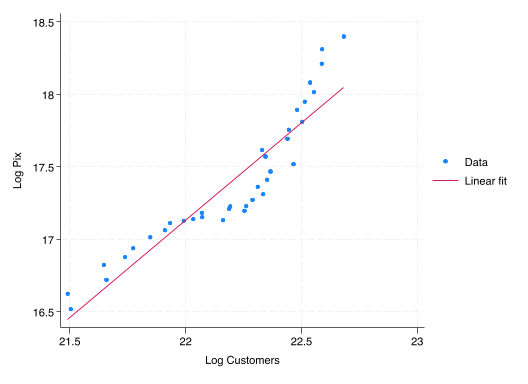

In [18]:
twoway ///
    (scatter l_cust l_pix) (lfit l_cust l_pix), ///
    xtitle("Log Customers") ytitle("Log Pix") ///
    legend(label(1 "Data") label(2 "Linear fit"))

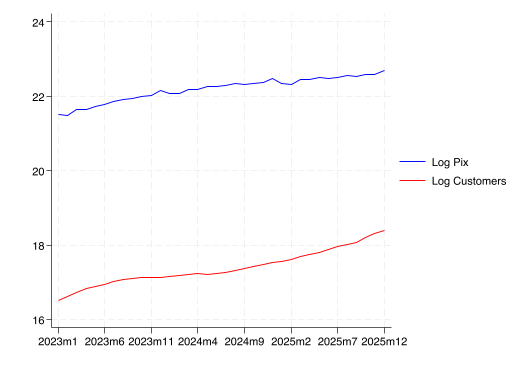

In [19]:
twoway ///
    (line l_pix mdate, sort lcolor(blue)) ///
    (line l_cust mdate, sort lcolor(red)), ///
    legend(order(1 "Log Pix" 2 "Log Customers")) ///
	xtitle(" ") ytitle(" ") ///
    xlabel(`=tm(2023m1)'(5)`=tm(2025m12)', format(%tm))

### Part 2. Baseline Regression Analysis

- We compute heteroskedasticity- and autocorrelation-consistent (HAC) standard errors to account for potential conditional heteroskedasticity and serial correlation in the regression residuals. <br>

- Specifically, we use the Newey–West estimator. And we select the truncation parameter p following a standard data-dependent rule-of-thumb, setting $p = n^{1/4}$, where n denotes the sample size.

In [20]:
newey l_pix l_cust, lag(3)


Regression with Newey–West standard errors      Number of obs     =         36
Maximum lag = 3                                 F(  1,        34) =      57.52
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
       l_pix | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      l_cust |   .6393351   .0842977     7.58   0.000     .4680216    .8106487
       _cons |   11.07438   1.473028     7.52   0.000     8.080825    14.06793
------------------------------------------------------------------------------


In [21]:
newey l_pix l_cust selic ibc_br, lag(3)


Regression with Newey–West standard errors      Number of obs     =         36
Maximum lag = 3                                 F(  3,        32) =     432.81
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
       l_pix | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      l_cust |   .7098683   .0413578    17.16   0.000     .6256253    .7941114
       selic |  -.0714091   .0067139   -10.64   0.000    -.0850848   -.0577335
      ibc_br |   .0058391   .0028057     2.08   0.046      .000124    .0115541
       _cons |   10.14146   .5493927    18.46   0.000     9.022388    11.26054
------------------------------------------------------------------------------


### Part 3. Regression Analysis Using Detrended Series

- Detrending is necessary because non-stationary variables with common time trends can produce spurious regression results. Even when no meaningful economic relationship exists, series may appear highly correlated, leading to biased inference and overstated significance. <br>

- Eliminating deterministic trends helps concentrate on short-run variation in the data and reduces the risk of misleading inference, thereby improving the reliability and robustness of the estimated relationship.

In [22]:
qui reg l_pix mdate
predict l_pix_re, resid
qui reg l_cust mdate
predict l_cust_re, resid

In [23]:
newey l_pix_re l_cust_re, lag(3)


Regression with Newey–West standard errors      Number of obs     =         36
Maximum lag = 3                                 F(  1,        34) =       2.04
                                                Prob > F          =     0.1622

------------------------------------------------------------------------------
             |             Newey–West
    l_pix_re | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
   l_cust_re |  -.2090694   .1463429    -1.43   0.162    -.5064739    .0883351
       _cons |  -3.44e-15   .0219633    -0.00   1.000    -.0446348    .0446348
------------------------------------------------------------------------------


### Part 4. Interrupted Time Series

In [24]:
clear all
import excel "/Users/xiezuoye/Desktop/Capstone/Brazil_Open_Finance/data_monthly.xlsx", sheet("data2") firstrow

(5 vars, 71 obs)


In [25]:
gen mdate = monthly(month, "MY")
format mdate %tm
tsset mdate

(9 missing values generated)

Time variable: mdate, 2020m11 to 2025m12
        Delta: 1 month


In [26]:
gen l_pix = log(pix)
gen t = _n
gen post = (mdate >= tm(2021m11))
gen t_post = (mdate - tm(2021m11) + 1) * post

(9 missing values generated)
(9 missing values generated)


- **Specification:**

$$
\text{l\_pix}_t
=
\alpha
+ \beta_1 t
+ \beta_2 \text{post}_t
+ \beta_3 (t \times \text{post}_t)
+ \gamma_1 \text{selic}_t
+ \gamma_2 \text{ibc\_br}_t
+ \varepsilon_t
$$


In [27]:
newey l_pix t post t_post selic ibc_br, lag(3)


Regression with Newey–West standard errors      Number of obs     =         62
Maximum lag = 3                                 F(  5,        56) =     135.90
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
       l_pix | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           t |   .2700651   .0475727     5.68   0.000     .1747656    .3653646
        post |  -.0445449   .2254698    -0.20   0.844    -.4962152    .4071254
      t_post |  -.2332073   .0470379    -4.96   0.000    -.3274355   -.1389791
       selic |  -.0208019   .0195517    -1.06   0.292    -.0599687    .0183649
      ibc_br |   .0054799   .0059662     0.92   0.362    -.0064717    .0174315
       _cons |   17.45733   .5460152    31.97   0.000     16.36353    18.55113
------------

In [28]:
predict l_pix_hat

(option xb assumed; fitted values)
(9 missing values generated)


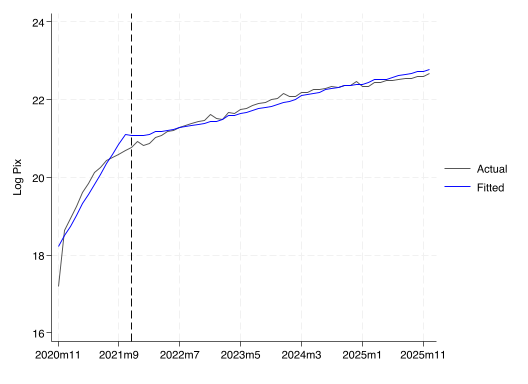

In [29]:
twoway ///
    (line l_pix mdate, sort lcolor(gs5)) ///
    (line l_pix_hat mdate, sort lcolor(blue)), ///
    legend(order(1 "Actual" 2 "Fitted")) ///
    xtitle("") ytitle("Log Pix") ///
    xlabel(`=tm(2020m11)'(10)`=tm(2025m12)', format(%tm)) ///
    xline(`=tm(2021m11)', lpattern(dash))

- **Interpretations:** <br>

    - The results from the interrupted time series (ITS) regression with Newey–West standard errors (lag = 3) indicate a clear structural change in the growth dynamics of Pix following the formal implementation of [Open Finance in November 2021](https://www.bcb.gov.br/en/financialstability/open_finance). We select November 2021 as the official start date of Open Finance because this marks the end of Phase 3, which is when services were formally launched.
    
    - Prior to November 2021, Pix exhibited a strong and statistically significant upward trend. The coefficient of the time variable `t` (0.270, p < 0.001) implies that on average, during the pre-policy period, Pix has a monthly growth rate of roughly 31%. <br>

    - The coefficient of the `post` dummy is negative but statistically insignificant (-0.045, p = 0.844), suggesting that the implementation of Open Finance did not generate an immediate level shift in Pix transactions. In other words, there is no evidence of a discrete jump in Pix activity at the moment of policy implementation. <br>

    - However, the interaction term capturing the post-intervention trend change `t_post` is negative and highly significant (-0.233, p < 0.001). This implies a substantial reduction in the slope of the time trend after November 2021. Combining the pre-policy trend with the post-policy adjustment yields a post-policy trend of approximately 3.8% monthly growth rate. Thus, while Pix continued to expand after the implementation of Open Finance, its growth rate declined significantly relative to the initial expansion phase. Several factors may explain this phenomenon: <br>

        - First, the early period of Pix was characterized by rapid diffusion and strong network externalities, typical of digital platform adoption. Once a critical mass of users and merchants had joined the system, marginal growth naturally declined as market penetration increased and the pool of new adopters shrank. <br>

        -  Second, part of the initial expansion reflected a substitution effect, as consumers shifted from cash, bank transfers, and cards to Pix. However, once this substitution process matured, incremental gains became smaller. <br>
        
        - Finally, Open Finance may have contributed to a structural normalization of the payment ecosystem, shifting the system from an explosive adoption phase to a more stable, efficiency-driven expansion path.